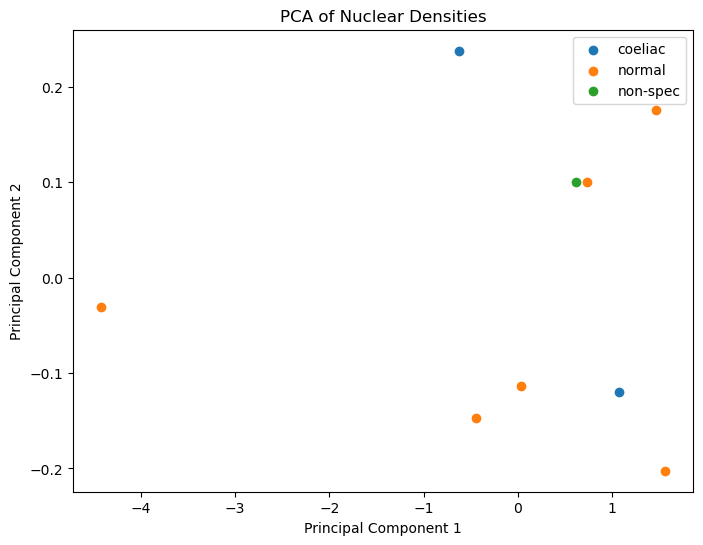

Explained variance ratio: [0.99266632 0.00733368]


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

os.chdir('/rds/user/mf774/hpc-work/part_II_project/in-house/training-CD3/validation/analysis/')
# Load the data
data = pd.read_csv("summary_density_diagnosis.csv")  # Replace with the actual filename

# Select relevant columns for PCA
features = ["pos_nuc_density", "neg_nuc_density", "total_nuc_density"]
X = data[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame with PCA results
data_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
data_pca["diagnosis"] = data["diagnosis"]  # Add diagnosis for coloring

# Plot the PCA results
plt.figure(figsize=(8, 6))
for diagnosis in data_pca["diagnosis"].unique():
    subset = data_pca[data_pca["diagnosis"] == diagnosis]
    plt.scatter(subset["PC1"], subset["PC2"], label=diagnosis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Nuclear Densities")
plt.legend()
plt.show()

# Print explained variance ratio
print("Explained variance ratio:", pca.explained_variance_ratio_)